This project focuses on forecasting household energy consumption using historical time-series data. The dataset is preprocessed and resampled to hourly intervals, followed by feature engineering using time-based variables such as hour, day, weekday, and lag values. Three models—ARIMA, Prophet, and XGBoost—are implemented and compared to evaluate their performance using MAE and RMSE. The results are visualized by plotting actual vs predicted energy usage to analyze model accuracy and temporal patterns in electricity consumption.

In [3]:
import pandas as pd

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sarahashmi/household-power-consumption-txt")

print("Path to dataset files:", path)

100%|██████████| 19.4M/19.4M [00:00<00:00, 92.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sarahashmi/household-power-consumption-txt/versions/1


In [6]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/sarahashmi/household-power-consumption-txt/versions/1/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    low_memory=False,
    na_values=['?']
)

/tmp/ipykernel_16490/3760017550.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_16490/3760017550.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [7]:
df = df.replace('?', pd.NA)

In [9]:
df.isnull().sum()

,0
Datetime,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [10]:
df = df.dropna()

In [12]:
df

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2075254,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [13]:
df['Global_active_power'] = df['Global_active_power'].astype(float)
df = df.set_index('Datetime')

In [14]:
df_hourly = df['Global_active_power'].resample('H').mean()
df_hourly = df_hourly.dropna()

/tmp/ipykernel_16490/844842886.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['Global_active_power'].resample('H').mean()


In [15]:
data = df_hourly.to_frame()

data['hour'] = data.index.hour
data['day'] = data.index.day
data['weekday'] = data.index.weekday
data['is_weekend'] = (data['weekday'] >= 5).astype(int)

# Lag features (very important)
data['lag_1'] = data['Global_active_power'].shift(1)
data['lag_24'] = data['Global_active_power'].shift(24)

data = data.dropna()

In [16]:
split = int(len(data) * 0.8)

train = data.iloc[:split]
test = data.iloc[split:]

In [19]:
# Model 1: ARIMA
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['Global_active_power'], order=(5,1,0))
model_fit = model_arima.fit()

arima_pred = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [26]:
# Model 2: Prophet (Meta Model)
from prophet import Prophet

prophet_data = df_hourly.reset_index()
prophet_data.columns = ['ds', 'y']

train_p = prophet_data.iloc[:split]
test_p = prophet_data.iloc[split:]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p), freq='H')
forecast = model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [27]:
# Model 3: XGBoost (ML Model)
from xgboost import XGBRegressor

features = ['hour','day','weekday','is_weekend','lag_1','lag_24']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [28]:
# Evaluation (MAE, RMSE)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.4f}, RMSE: {rmse:.4f}")

evaluate(test['Global_active_power'], arima_pred, "ARIMA")
evaluate(test['Global_active_power'], prophet_pred, "Prophet")
evaluate(test['Global_active_power'], xgb_pred, "XGBoost")

ARIMA → MAE: 0.7666, RMSE: 0.8873
Prophet → MAE: 0.6550, RMSE: 0.8216
XGBoost → MAE: 0.3459, RMSE: 0.4974


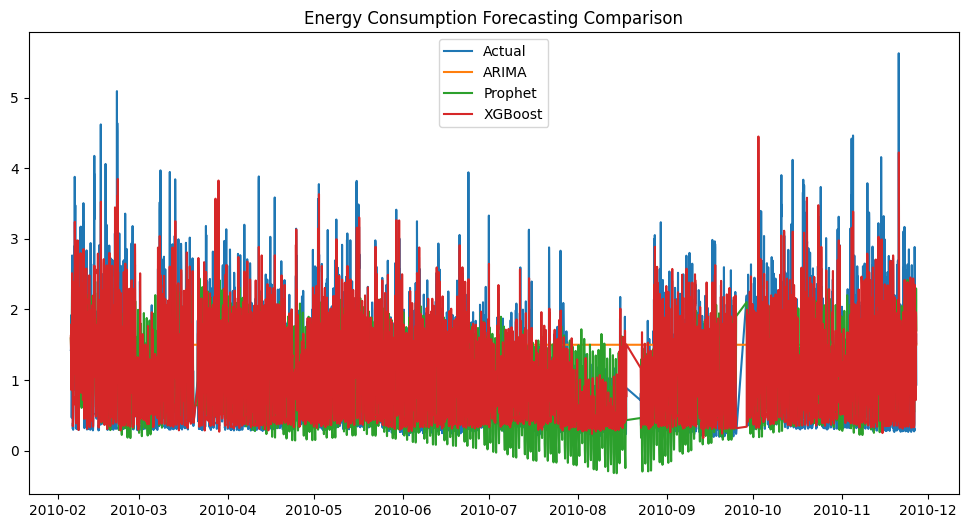

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Energy Consumption Forecasting Comparison")
plt.show()